In [ ]:
!unzip -q auta.zip -d dataset/

In [ ]:
import os, torch, random
import numpy as np
from glob import glob
from PIL import Image
from torch.utils.data import random_split, Dataset, DataLoader
from torchvision import transforms as T

Image.MAX_IMAGE_PIXELS = None
torch.manual_seed(2025)

class CustomDataset(Dataset):
    def __init__(self, root, cls_names=None, transformations=None):
        self.transformations = transformations
        self.im_paths = glob(f"{root}/*/*.jpg") + glob(f"{root}/*/*.png") + glob(f"{root}/*/*.jpeg")
        self.cls_names, self.cls_counts, count = {} if not cls_names else cls_names, {}, 0

        for idx, im_path in enumerate(self.im_paths):
            cls_name = self.get_cls_name(im_path)
            if self.cls_names is not None:
                if cls_name not in self.cls_names:
                    self.cls_names[cls_name] = count
                    count += 1
            if cls_name not in self.cls_counts:
                self.cls_counts[cls_name] = 1
            else:
                self.cls_counts[cls_name] += 1

    def get_cls_name(self, path):
        return os.path.basename(os.path.dirname(path))

    def __len__(self):
        return len(self.im_paths)

    def get_pos_neg_im_paths(self, qry_label):
        pos_im_paths = [im_path for im_path in self.im_paths if qry_label == self.get_cls_name(im_path)]
        neg_im_paths = [im_path for im_path in self.im_paths if qry_label != self.get_cls_name(im_path)]

        pos_rand_int = random.randint(a=0, b=len(pos_im_paths) - 1)
        neg_rand_int = random.randint(a=0, b=len(neg_im_paths) - 1)

        return pos_im_paths[pos_rand_int], neg_im_paths[neg_rand_int]

    def __getitem__(self, idx):
        im_path = self.im_paths[idx]
        qry_im = Image.open(im_path).convert("RGB")
        qry_label = self.get_cls_name(im_path)

        pos_im_path, neg_im_path = self.get_pos_neg_im_paths(qry_label=qry_label)
        pos_im, neg_im = Image.open(pos_im_path).convert("RGB"), Image.open(neg_im_path).convert("RGB")

        qry_gt = self.cls_names[qry_label]
        neg_gt = self.cls_names[self.get_cls_name(neg_im_path)]

        if self.transformations is not None:
            qry_im = self.transformations(qry_im)
            pos_im = self.transformations(pos_im)
            neg_im = self.transformations(neg_im)

        data = {
            "qry_im": qry_im,
            "qry_gt": qry_gt,
            "pos_im": pos_im,
            "neg_im": neg_im,
            "neg_gt": neg_gt
        }
        return data

def get_dls(root, transformations, bs, split=[0.8, 0.1, 0.1], ns=2):
    ds = CustomDataset(root=root, transformations=transformations)
    cls_names = ds.cls_names
    cls_counts = ds.cls_counts

    total_len = len(ds)
    tr_len = int(total_len * split[0])
    vl_len = int(total_len * split[1])
    ts_len = total_len - tr_len - vl_len

    tr_ds, vl_ds, ts_ds = random_split(dataset=ds, lengths=[tr_len, vl_len, ts_len])

    tr_dl = DataLoader(tr_ds, batch_size=bs, shuffle=True, num_workers=ns)
    val_dl = DataLoader(vl_ds, batch_size=bs, shuffle=False, num_workers=ns)
    ts_dl = DataLoader(ts_ds, batch_size=1, shuffle=False, num_workers=ns)

    return tr_dl, val_dl, ts_dl, cls_names, cls_counts

# --- START ---
root = "dataset"
mean, std, size, bs = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], 224, 16
tfs = T.Compose([T.ToTensor(), T.Resize(size=(size, size), antialias=False), T.Normalize(mean=mean, std=std)])

print("Przygotowanie danych")
tr_dl, val_dl, ts_dl, classes, cls_counts = get_dls(root=root, transformations=tfs, bs=bs)

print(f"Ilość marek: {len(classes)}")
print(f"Znalezione klasy: {list(classes.keys())[:5]} ... (5 pierwszych)")

Przygotowanie danych
Ilość marek: 50
Znalezione klasy: ['Dodge', 'Nissan', 'Land Rover', 'Mazda', 'Cadillac'] ... (5 pierwszych)


In [ ]:
import timm
import torch.nn as nn
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Trenowanie na: {device}")

print("Pobieranie ResNet50...")
model = timm.create_model('resnet50', pretrained=True, num_classes=len(classes))
model = model.to(device)

ce_loss_fn = nn.CrossEntropyLoss()
cs_loss_fn = nn.CosineEmbeddingLoss(margin=0.3)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 15
best_acc = 0.0

print("\nROZPOCZECIE TRENINGU ")

for epoch in range(epochs):
    model.train()
    train_acc, train_loss = 0, 0

    print(f"\n--- Epoka {epoch+1}/{epochs} ---")

    for batch in tqdm(tr_dl, desc="Trening", colour="green"):
        qry_im = batch["qry_im"].to(device)
        pos_im = batch["pos_im"].to(device)
        neg_im = batch["neg_im"].to(device)
        qry_gt = batch["qry_gt"].to(device)

        curr_bs = qry_im.shape[0]

        optimizer.zero_grad()

        qry_logits = model(qry_im)
        pos_logits = model(pos_im)

        qry_features = model.forward_features(qry_im).mean(dim=[2,3])
        pos_features = model.forward_features(pos_im).mean(dim=[2,3])
        neg_features = model.forward_features(neg_im).mean(dim=[2,3])

        ce_loss = ce_loss_fn(qry_logits, qry_gt) + ce_loss_fn(pos_logits, qry_gt)

        cs_pos_lbl = torch.ones(curr_bs).to(device)
        cs_neg_lbl = -torch.ones(curr_bs).to(device)

        cs_loss = cs_loss_fn(qry_features, pos_features, cs_pos_lbl) + cs_loss_fn(qry_features, neg_features, cs_neg_lbl)

        loss = ce_loss + cs_loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += (torch.argmax(qry_logits, dim=1) == qry_gt).sum().item()

    model.eval()
    val_acc = 0
    with torch.no_grad():
        for batch in tqdm(val_dl, desc="Sprawdzanie", colour="blue"):
            qry_im = batch["qry_im"].to(device)
            qry_gt = batch["qry_gt"].to(device)
            logits = model(qry_im)
            val_acc += (torch.argmax(logits, dim=1) == qry_gt).sum().item()

    t_acc = train_acc / len(tr_dl.dataset)
    v_acc = val_acc / len(val_dl.dataset)

    print(f"Skuteczność (Z mat. uczył się): {t_acc*100:.1f}%")
    print(f"Skuteczność (Z mat. nowego):    {v_acc*100:.1f}%")

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), 'najlepszy_model_pytorch.pth')
        print(" Zapisano nowy najlepszy model.")

print(f"\n Trening zakończony. Najlepszy wynik na walidacji: {best_acc*100:.1f}%")

Trenowanie na: cuda
Pobieranie ResNet50...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


ROZPOCZECIE TRENINGU 

--- Epoka 1/15 ---


Sprawdzanie: 100%|██████████| 29/29 [00:09<00:00,  3.09it/s]


...

Skuteczność (Z mat. uczył się): 99.5%
Skuteczność (Z mat. nowego):    98.0%
 Zapisano nowy najlepszy model.

--- Epoka 14/15 ---


Sprawdzanie: 100%|██████████| 29/29 [00:07<00:00,  3.88it/s]


Skuteczność (Z mat. uczył się): 99.4%
Skuteczność (Z mat. nowego):    99.3%
 Zapisano nowy najlepszy model.

--- Epoka 15/15 ---


Sprawdzanie: 100%|██████████| 29/29 [00:07<00:00,  3.87it/s]

Skuteczność (Z mat. uczył się): 99.5%
Skuteczność (Z mat. nowego):    99.1%

 Trening zakończony. Najlepszy wynik na walidacji: 99.3%



🔍 Generowanie PEŁNEJ Macierzy Pomyłek (Zbiór Treningowy + Walidacyjny)...
📊 Rysowanie wykresu...


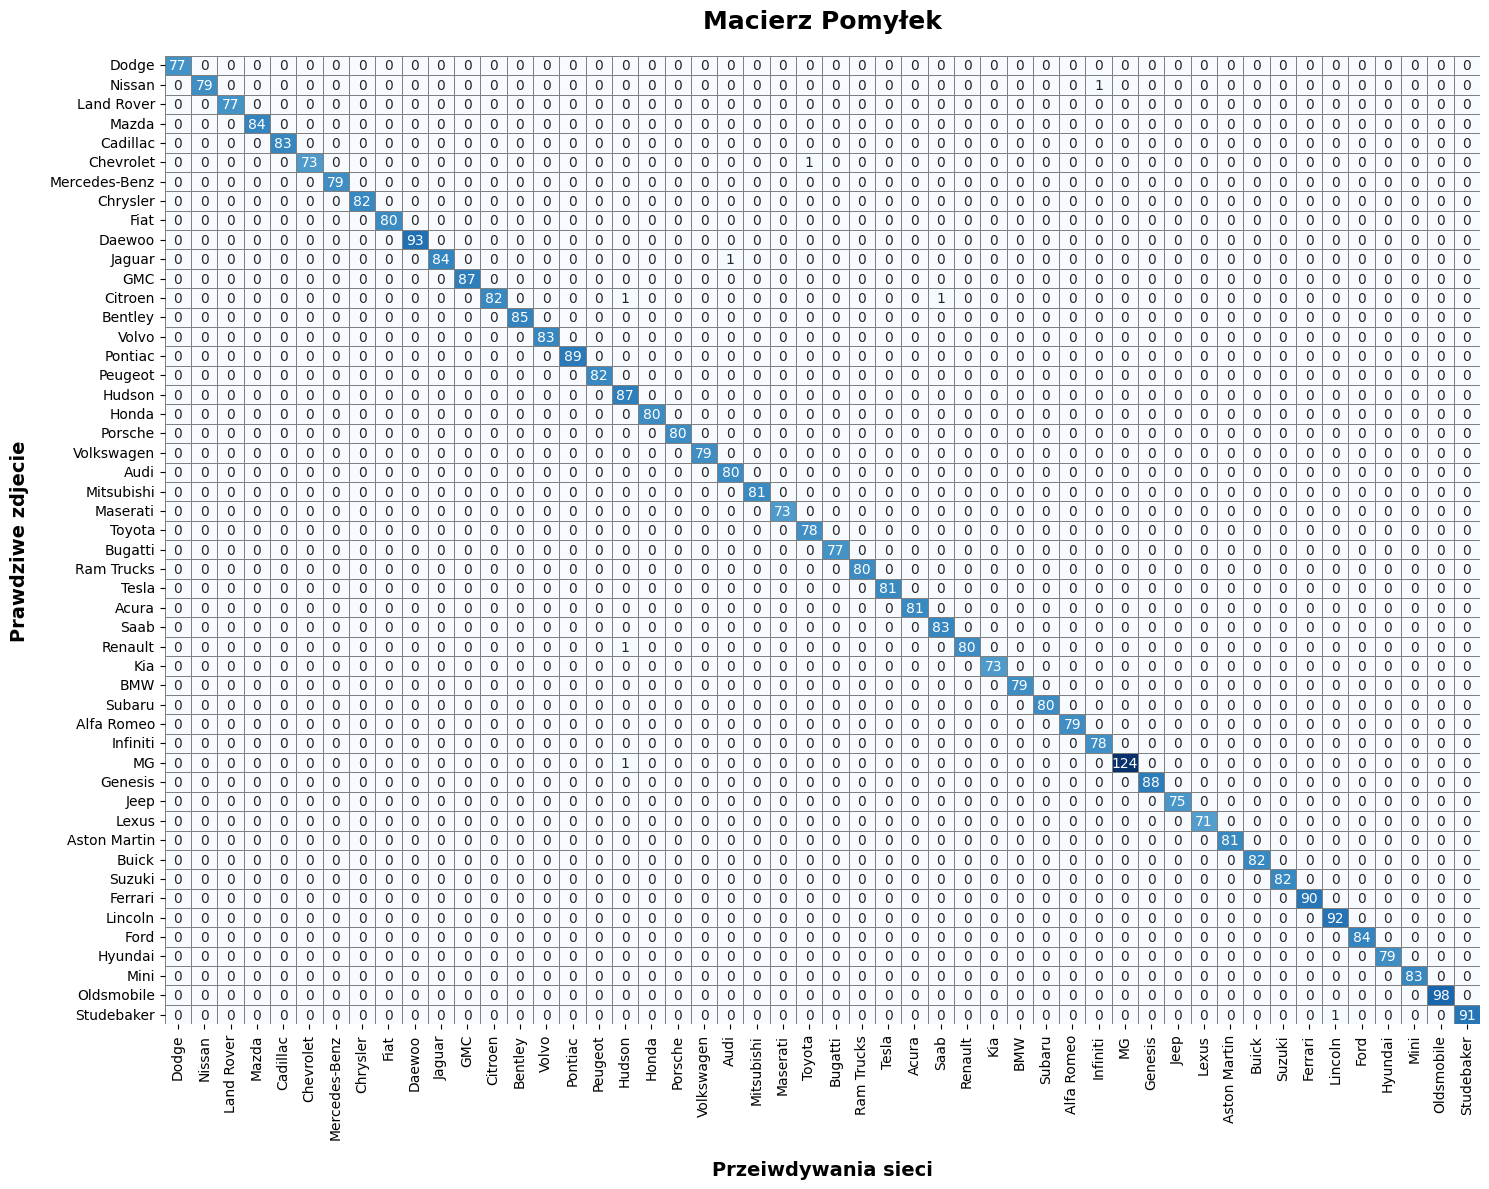

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

print("\n🔍 Generowanie PEŁNEJ Macierzy Pomyłek (Zbiór Treningowy + Walidacyjny)...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

y_prawdziwe = []
y_przewidziane = []

nazwy_klas = [k for k, v in sorted(classes.items(), key=lambda item: item[1])]

with torch.no_grad():
    for dl in [tr_dl, val_dl]:
        for batch in dl:
            qry_im = batch["qry_im"].to(device)
            qry_gt = batch["qry_gt"].to(device)

            logits = model(qry_im)
            preds = torch.argmax(logits, dim=1)

            y_prawdziwe.extend(qry_gt.cpu().numpy())
            y_przewidziane.extend(preds.cpu().numpy())

print("📊 Rysowanie wykresu...")

cm = confusion_matrix(y_prawdziwe, y_przewidziane)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nazwy_klas, yticklabels=nazwy_klas,
            cbar=False, linewidths=0.5, linecolor='gray')

plt.xlabel('Przeiwdywania sieci', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Prawdziwe zdjecie', fontsize=14, fontweight='bold', labelpad=15)
plt.title('Macierz Pomyłek', fontsize=18, fontweight='bold', pad=20)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image

print("\n🧠 TESTUJEMY NOWE ZDJĘCIE...")
sciezka_do_zdjecia = 'auto1.jpg'

try:
    obrazek = Image.open(sciezka_do_zdjecia).convert("RGB")
    obrazek_tensor = tfs(obrazek).unsqueeze(0).to(device)

    model.load_state_dict(torch.load('najlepszy_model_pytorch.pth', map_location=device, weights_only=True))
    model.eval()

    odwrotne_klasy = {v: k for k, v in classes.items()}

    with torch.no_grad():
        wyniki = model(obrazek_tensor)
        prawdopodobienstwa = F.softmax(wyniki, dim=1)[0]
        top3_pewnosc, top3_indeksy = torch.topk(prawdopodobienstwa, 3)

    print("\n" + "="*50)
    print("📸 WYNIK ROZPOZNAWANIA:")
    print("="*50)

    for i in range(3):
        procent = top3_pewnosc[i].item() * 100
        marka = odwrotne_klasy[top3_indeksy[i].item()]

        if i == 0:
            print(f"🥇 1. MIEJSCE: {marka.upper():<20} ({procent:.1f}% pewności)")
        else:
            print(f"   {i+1}. MIEJSCE: {marka:<20} ({procent:.1f}%)")

    print("="*50)

except FileNotFoundError:
    print("❌ BŁĄD: Nie znaleziono pliku 'testowe.jpg'! Upewnij się, że wgrałeś go do panelu po lewej stronie i że tak właśnie się nazywa.")
except Exception as e:
    print(f"❌ Inny błąd: {e}")


🧠 TESTUJEMY NOWE ZDJĘCIE...

📸 WYNIK ROZPOZNAWANIA:
🥇 1. MIEJSCE: FIAT                 (99.4% pewności)
   2. MIEJSCE: Renault              (0.4%)
   3. MIEJSCE: Citroen              (0.1%)
